In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x_or_283 = pd.read_csv('吸附曲线用数据/fau-co2-283-1.csv')
x_fit_283 = pd.read_csv('../spline/fau-co2-283-1.csv')
len(x_or_283['pressure'])
# x_fit_283.head()

37

In [3]:
from sklearn.metrics import mean_squared_error, r2_score
from scipy.interpolate import UnivariateSpline
files_or = {
    '283K': '吸附曲线用数据/fau-co2-283-1.csv',
    '298K': '吸附曲线用数据/fau-co2-298-1.csv',
    '323K': '吸附曲线用数据/fau-co2-323-1.csv',
    '348K': '吸附曲线用数据/fau-co2-348-1.csv'
}
files_fit = {
    '283K': '../spline/fau-co2-283-1.csv',
    '298K': '../spline/fau-co2-298-1.csv',
    '323K': '../spline/fau-co2-323-1.csv',
    '348K': '../spline/fau-co2-348-1.csv'
}


def plot(ori_data, fit_data, temp_label, a=False):
    fit_data = fit_data[fit_data['Adsorption (mmol/g)']>0]
    # 获取原始数据的压力和吸附量
    P_ori = ori_data['pressure'].values
    Q_ori = ori_data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
    if a == True:
        print('FITTING')
        df = ori_data
        # 移除重复和空值数据，确保数据合理性
        df = df.drop_duplicates()
        # df = df.dropna()
        df = df[df['pressure'] > 0]  # 过滤不合理的压力值
    
        # # 如果数据点太少，不进行插值
        # if len(df) < 5:
        #     print("数据点不足，无法进行有效插值")
        #     return pd.DataFrame(columns=['Pressure (bar)', 'Adsorption (mmol/g)'])
    
        # 检查并移除异常值（如超过3倍标准差的点）
        df = df[
            np.abs(df['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'] - df['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].mean()) <= (3 * df['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].std())]
    
        # 按压力值排序，确保数据是递增的
        df = df.sort_values('pressure')
    
        pressure = df['pressure'].values
        adsorption = df['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
    
        # 样条插值拟合
        try:
            spline = UnivariateSpline(pressure, adsorption, s=0.015)  # 使用适当的平滑因子
            new_pressures = np.linspace(pressure.min(), pressure.max(), 1000)
            new_adsorptions = spline(new_pressures)
    
            # 检查插值结果中是否存在 NaN
            if np.any(np.isnan(new_adsorptions)):
                print("警告: 拟合结果中包含 NaN 值")
                
    
        except Exception as e:
            print(f"插值时出错: {e}")
        
        P_fit = new_pressures
        Q_fit = new_adsorptions
            
    else:
        # 获取拟合数据的压力和吸附量
        P_fit = fit_data['Pressure (bar)'].values
        Q_fit = fit_data['Adsorption (mmol/g)'].values
    
    # 合并两个数据集，基于最接近的压力值进行匹配
    merged_data = pd.merge_asof(ori_data.sort_values(by='pressure'), 
                                fit_data.sort_values(by='Pressure (bar)'), 
                                left_on='pressure', 
                                right_on='Pressure (bar)', 
                                direction='nearest',tolerance=1e10)
    
    # 检查合并后的数据是否为空
    if merged_data.empty:
        print(f"{temp_label}: 合并后的 DataFrame 为空，无法计算误差。请检查数据范围或合并条件。")
        return P_ori, Q_ori, P_fit, Q_fit
    
    print(len(merged_data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)']))
    # print(merged_data)
    # 提取匹配后的吸附量用于误差计算
    Q_ori_merged = merged_data['adsorption (CURLTUGMZLYLDI-UHFFFAOYSA-N)'].values
    Q_fit_merged = merged_data['Adsorption (mmol/g)'].values

    # 计算误差
    mean_error = np.mean(Q_ori_merged - Q_fit_merged)
    max_error = max(abs(Q_ori_merged - Q_fit_merged))
    relative_error = np.mean(np.abs((Q_ori_merged - Q_fit_merged) / Q_ori_merged)) * 100
    mse = mean_squared_error(Q_ori_merged, Q_fit_merged)
    r2 = r2_score(Q_ori_merged, Q_fit_merged)

    # 输出拟合结果和误差
    print(f"{temp_label} 平均误差: {mean_error:.5f}")
    print(f"{temp_label} 最大误差: {max_error:.5f}")
    print(f"{temp_label} 相对误差: {relative_error:.2f}%")
    print(f"{temp_label} MSE: {mse:.5f}")
    print(f"{temp_label} R²: {r2:.5f}")

    # 返回压力和吸附量
    return P_ori, Q_ori, P_fit, Q_fit

# 调用函数并传入相应的数据
# 假设 x_or_283 和 x_fit_283 是已经加载的 DataFrame
P_ori, Q_ori, P_fit, Q_fit = plot(x_or_283, x_fit_283, "283K")

37
283K 平均误差: 0.11886
283K 最大误差: 0.96337
283K 相对误差: 26.15%
283K MSE: 0.07797
283K R²: 0.98395


37
283K 平均误差: 0.11886
283K 最大误差: 0.96337
283K 相对误差: 26.15%
283K MSE: 0.07797
283K R²: 0.98395
35
298K 平均误差: 0.05989
298K 最大误差: 0.59111
298K 相对误差: 21.09%
298K MSE: 0.02597
298K R²: 0.99363
31
323K 平均误差: 0.00764
323K 最大误差: 0.14018
323K 相对误差: 10.92%
323K MSE: 0.00183
323K R²: 0.99934
FITTING
30
348K 平均误差: 0.00454
348K 最大误差: 0.16823
348K 相对误差: 5.35%
348K MSE: 0.00117
348K R²: 0.99934


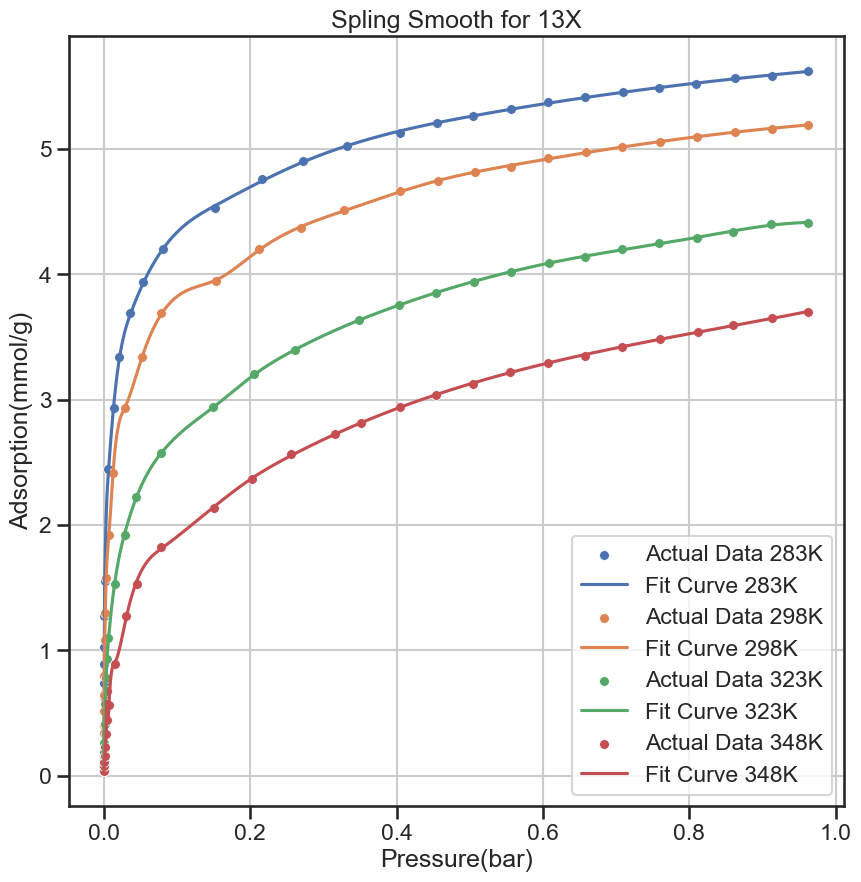

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置Seaborn的样式
sns.set(style="ticks")
sns.set_context('talk')

# 整合多个数据文件
plt.figure(figsize=(10, 10))

# 循环处理所有文件并绘制
for temp_label in files_or.keys():
    ori_data = pd.read_csv(files_or[temp_label])
    fit_data = pd.read_csv(files_fit[temp_label])
    a = False
    if temp_label == '348K':
        a = True
    
    # 调用拟合和绘制函数
    P_ori, Q_ori, P_fit, Q_fit = plot(ori_data, fit_data, temp_label, a)
    
    # 绘制实际数据点
    sns.scatterplot(x=P_ori, y=Q_ori, label=f'Actual Data {temp_label}', s=50)
    # 绘制拟合曲线
    sns.lineplot(x=P_fit, y=Q_fit, label=f'Fit Curve {temp_label}')

# 图形设置
# plt.xscale('log')  # 使用对数坐标轴
plt.xlabel('Pressure(bar)')
plt.ylabel('Adsorption(mmol/g)')
plt.title('Spling Smooth for 13X')
plt.legend()
plt.grid(True)

# 显示图形
plt.show()

14
298K 平均误差: 0.00183
298K 最大误差: 0.01896
298K 相对误差: 4.89%
298K MSE: 0.00010
298K R²: 0.99983
14
323K 平均误差: -0.00001
323K 最大误差: 0.01881
323K 相对误差: 17.07%
323K MSE: 0.00008
323K R²: 0.99954
11
348K 平均误差: 0.00003
348K 最大误差: 0.01856
348K 相对误差: 7.78%
348K MSE: 0.00010
348K R²: 0.99839


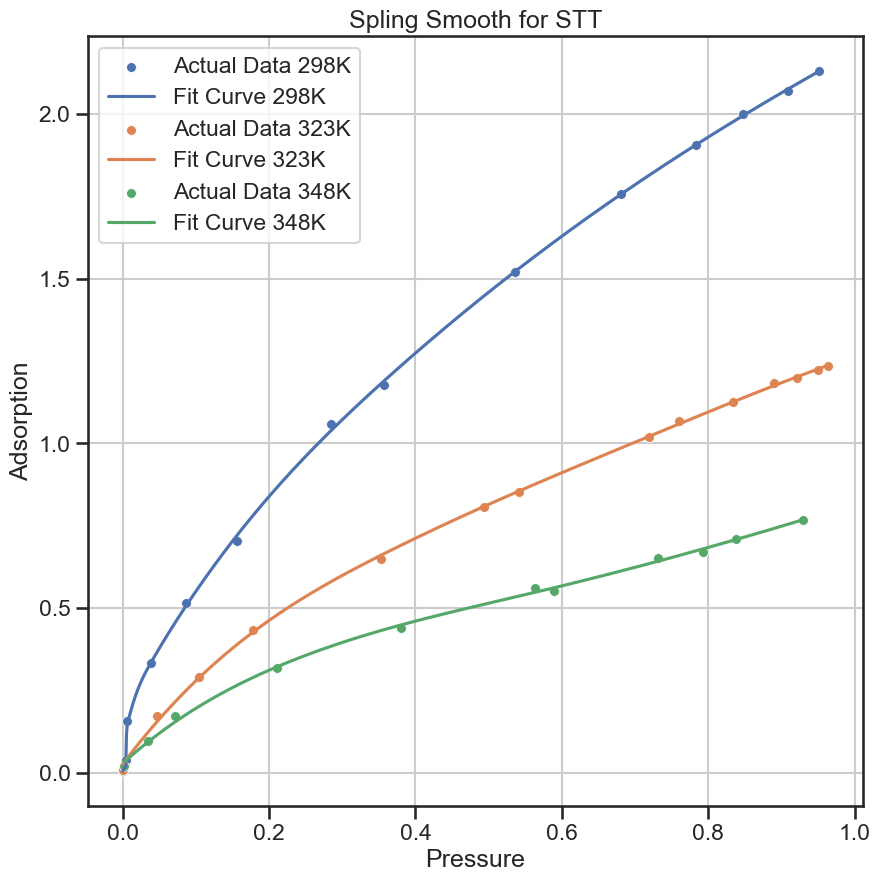

In [6]:
files_or_stt = {
    '298K': '吸附曲线用数据/stt-co2-298-1.csv',
    '323K': '吸附曲线用数据/stt-co2-323-1.csv',
    '348K': '吸附曲线用数据/stt-co2-348-1.csv'
}
files_fit_stt = {
    '298K': '../spline/stt-co2-298-1.csv',
    '323K': '../spline/stt-co2-323-1.csv',
    '348K': '../spline/stt-co2-348-1.csv'
}
import seaborn as sns
import matplotlib.pyplot as plt

# 设置Seaborn的样式
sns.set(style="ticks")
sns.set_context('talk')

# 整合多个数据文件
plt.figure(figsize=(10, 10))

# 循环处理所有文件并绘制
for temp_label_stt in files_or_stt.keys():
    ori_data_stt = pd.read_csv(files_or_stt[temp_label_stt])
    fit_data_stt = pd.read_csv(files_fit_stt[temp_label_stt])
    
    # 调用拟合和绘制函数
    P_ori, Q_ori, P_fit, Q_fit = plot(ori_data_stt, fit_data_stt, temp_label_stt)
    
    # 绘制实际数据点
    sns.scatterplot(x=P_ori, y=Q_ori, label=f'Actual Data {temp_label_stt}', s=50)
    # 绘制拟合曲线
    sns.lineplot(x=P_fit, y=Q_fit, label=f'Fit Curve {temp_label_stt}')

# 图形设置
# plt.xscale('log')  # 使用对数坐标轴
plt.xlabel('Pressure')
plt.ylabel('Adsorption')
plt.title('Spling Smooth for STT')
plt.legend()
plt.grid(True)

# 显示图形
plt.show()